Cell 1: Setup

In [ ]:
import os, sys

if not os.path.exists("/content/ghostshot"):
    !git clone https://github.com/mohamedaazouni10-code/ghostshot.git /content/ghostshot

sys.path.insert(0, "/content/ghostshot")
os.chdir("/content/ghostshot")

from google.colab import drive
drive.mount("/content/drive")

import yaml
from pathlib import Path

with open("configs/base.yaml") as f:
    cfg = yaml.safe_load(f)

from src.utils import set_seed, get_device
set_seed(cfg["project"]["seed"])
device = get_device(cfg)

DRIVE_ROOT = "/content/drive/MyDrive/ghostshot"
links = {
    f"{DRIVE_ROOT}/data/raw":            "data/raw",
    f"{DRIVE_ROOT}/data/processed":      "data/processed",
    f"{DRIVE_ROOT}/data/attack_samples": "data/attack_samples",
    f"{DRIVE_ROOT}/models/checkpoints":  "models/checkpoints",
    f"{DRIVE_ROOT}/results":             "results",
}
for drive_path, local_link in links.items():
    os.makedirs(drive_path, exist_ok=True)
    os.makedirs(local_link, exist_ok=True)
    if not os.path.islink(local_link):
        os.rmdir(local_link)
        os.symlink(drive_path, local_link)

print(f"Ready. Device = {device}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[seed] All random seeds set to 42
[device] Using configured device: cuda
Ready. Device = cuda


Cell 2 — Install packages:

In [ ]:
!pip install -q timm torchvision \
  "albumentations>=1.4.15" \
  "scikit-learn>=1.5" \
  "wandb>=0.17" \
  "pandas>=2.2" \
  "matplotlib>=3.9" \
  "tqdm>=4.67" \
  "scipy>=1.13" \
  deepface facenet-pytorch insightface

Cell 3 — Clone SimSwap & download weights:

In [ ]:
!git clone https://github.com/neuralchen/SimSwap.git /content/SimSwap
%cd /content/SimSwap
!bash download-weights.sh

fatal: destination path '/content/SimSwap' already exists and is not an empty directory.
/content/SimSwap
--2026-05-09 12:10:15--  https://github.com/neuralchen/SimSwap/releases/download/1.0/arcface_checkpoint.tar
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/374891081/f01468b3-446b-4867-8c78-6d496183f9e6?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-05-09T12%3A44%3A11Z&rscd=attachment%3B+filename%3Darcface_checkpoint.tar&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-05-09T11%3A43%3A28Z&ske=2026-05-09T12%3A44%3A11Z&sks=b&skv=2018-11-09&sig=gPsSzkcY83WfLbQfjjREiQM5kWxgK%2FV3OHcMMogaGyE%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRl

Cell 4 — Fix antelope models:

In [ ]:
import insightface
from pathlib import Path
from insightface.app import FaceAnalysis

# Auto-download antelope
app = FaceAnalysis(
    name='antelopev2',
    root='/content/SimSwap/insightface_func',
    providers=['CUDAExecutionProvider']
)
app.prepare(ctx_id=0, det_size=(640, 640))
print("✅ Antelope ready!")

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /content/SimSwap/insightface_func/models/antelopev2/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /content/SimSwap/insightface_func/models/antelopev2/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /content/SimSwap/insightface_func/models/antelopev2/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /content/SimSwap/insightface_func/models/antelopev2/glintr100.onnx recognition ['None', 3, 112, 112] 127.5 127.5
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /content/SimSwap/insightface_func/models/antelopev2/scrfd_10g

In [ ]:
import shutil
from pathlib import Path

dst = Path("/content/SimSwap/insightface_func/models/antelopev2")

# Fix nested folders
for nested in dst.rglob("*.onnx"):
    if nested.parent != dst:
        shutil.move(str(nested), str(dst / nested.name))
        print(f"Moved: {nested.name}")

# Remove empty subdirs
for d in dst.iterdir():
    if d.is_dir():
        shutil.rmtree(d)
        print(f"Removed dir: {d.name}")

print("\nFinal contents:")
for f in dst.iterdir():
    print(f"  {f.name}")

Moved: glintr100.onnx
Moved: 1k3d68.onnx
Moved: scrfd_10g_bnkps.onnx
Moved: 2d106det.onnx
Moved: genderage.onnx
Removed dir: antelopev2

Final contents:
  glintr100.onnx
  1k3d68.onnx
  scrfd_10g_bnkps.onnx
  2d106det.onnx
  genderage.onnx


In [ ]:
%cd /content/SimSwap

source_path = "/content/ghostshot/data/processed/celebdf_real/0/id56_0003/id56_0003_f0000.png"
target_path = "/content/ghostshot/data/processed/celebdf_real/0/id9_0002/id9_0002_f0000.png"
output_dir  = "/content/ghostshot/data/attack_samples/generated/test/"

import os
os.makedirs(output_dir, exist_ok=True)

!python test_one_image.py \
    --isTrain false \
    --name people \
    --Arc_path arcface_model/arcface_checkpoint.tar \
    --pic_a_path {source_path} \
    --pic_b_path {target_path} \
    --output_path {output_dir}

%cd /content/ghostshot
print("✅ Done! Checking output...")
!ls data/attack_samples/generated/test/

/content/SimSwap
------------ Options -------------
Arc_path: arcface_model/arcface_checkpoint.tar
aspect_ratio: 1.0
batchSize: 8
checkpoints_dir: ./checkpoints
cluster_path: features_clustered_010.npy
crop_size: 512
data_type: 32
dataroot: ./datasets/cityscapes/
display_winsize: 512
engine: None
export_onnx: None
feat_num: 3
fineSize: 512
fp16: False
gpu_ids: [0]
how_many: 50
id_thres: 0.03
image_size: 224
input_nc: 3
instance_feat: False
isTrain: False
label_feat: False
label_nc: 0
latent_size: 512
loadSize: 1024
load_features: False
local_rank: 0
max_dataset_size: inf
multisepcific_dir: ./demo_file/multispecific
nThreads: 2
n_blocks_global: 6
n_blocks_local: 3
n_clusters: 10
n_downsample_E: 4
n_downsample_global: 3
n_local_enhancers: 1
name: people
nef: 16
netG: global
ngf: 64
niter_fix_global: 0
no_flip: False
no_instance: False
no_simswaplogo: False
norm: batch
norm_G: spectralspadesyncbatch3x3
ntest: inf
onnx: None
output_nc: 3
output_path: /content/ghostshot/data/attack_samples/

In [ ]:
# Fix the torch.load issue in SimSwap
!sed -i 's/torch.load(netArc_checkpoint, map_location=torch.device("cpu"))/torch.load(netArc_checkpoint, map_location=torch.device("cpu"), weights_only=False)/g' \
    /content/SimSwap/models/fs_model.py

# Verify the fix
!grep "torch.load" /content/SimSwap/models/fs_model.py

        netArc_checkpoint = torch.load(netArc_checkpoint, map_location=torch.device("cpu"), weights_only=False)


In [ ]:
%cd /content/SimSwap

!python test_one_image.py \
    --isTrain false \
    --name people \
    --Arc_path arcface_model/arcface_checkpoint.tar \
    --pic_a_path {source_path} \
    --pic_b_path {target_path} \
    --output_path {output_dir}

%cd /content/ghostshot
!ls data/attack_samples/generated/test/

/content/SimSwap
------------ Options -------------
Arc_path: arcface_model/arcface_checkpoint.tar
aspect_ratio: 1.0
batchSize: 8
checkpoints_dir: ./checkpoints
cluster_path: features_clustered_010.npy
crop_size: 512
data_type: 32
dataroot: ./datasets/cityscapes/
display_winsize: 512
engine: None
export_onnx: None
feat_num: 3
fineSize: 512
fp16: False
gpu_ids: [0]
how_many: 50
id_thres: 0.03
image_size: 224
input_nc: 3
instance_feat: False
isTrain: False
label_feat: False
label_nc: 0
latent_size: 512
loadSize: 1024
load_features: False
local_rank: 0
max_dataset_size: inf
multisepcific_dir: ./demo_file/multispecific
nThreads: 2
n_blocks_global: 6
n_blocks_local: 3
n_clusters: 10
n_downsample_E: 4
n_downsample_global: 3
n_local_enhancers: 1
name: people
nef: 16
netG: global
ngf: 64
niter_fix_global: 0
no_flip: False
no_instance: False
no_simswaplogo: False
norm: batch
norm_G: spectralspadesyncbatch3x3
ntest: inf
onnx: None
output_nc: 3
output_path: /content/ghostshot/data/attack_samples/

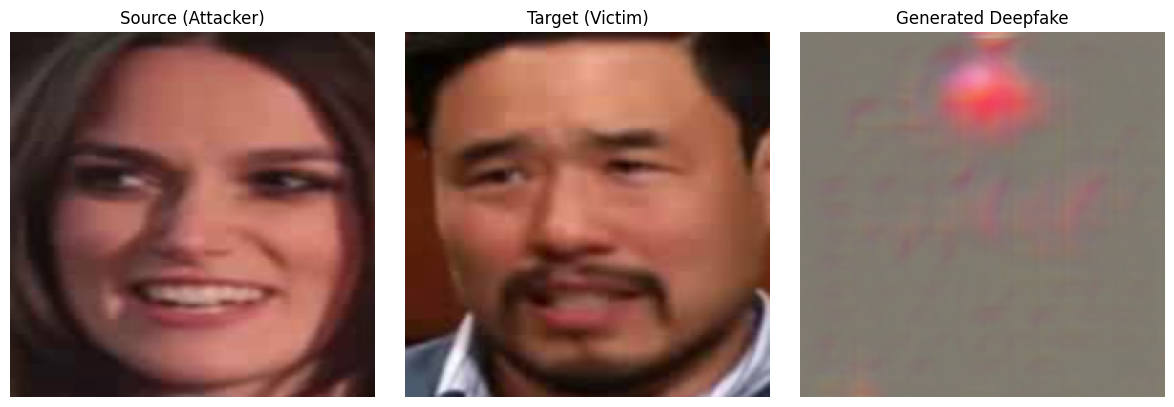

✅ SimSwap is working!


In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

source = Image.open(source_path)
target = Image.open(target_path)
result = Image.open("/content/ghostshot/data/attack_samples/generated/test/result.jpg")

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(source); axes[0].set_title("Source (Attacker)"); axes[0].axis("off")
axes[1].imshow(target); axes[1].set_title("Target (Victim)"); axes[1].axis("off")
axes[2].imshow(result); axes[2].set_title("Generated Deepfake"); axes[2].axis("off")

plt.tight_layout()
plt.savefig("results/figures/phase3_simswap_test.png", dpi=150)
plt.show()
print("✅ SimSwap is working!")

Cell 8: Run the Full Attack Campaign

In [ ]:
import random
import sys
import os
from pathlib import Path

random.seed(42)

# Rebuild victim pool
real_crops = []
for dataset in ["celebdf_real", "youtube_real"]:
    crop_dir = Path(f"data/processed/{dataset}/0")
    if crop_dir.exists():
        for identity_dir in crop_dir.iterdir():
            if identity_dir.is_dir():
                crops = list(identity_dir.glob("*.png"))
                if crops:
                    real_crops.append((identity_dir.name, str(crops[0])))

random.shuffle(real_crops)
selected = real_crops[:50]
victim_pool = {f"victim_{i:03d}": img_path
               for i, (_, img_path) in enumerate(selected)}

source_pool = [img_path for (_, img_path) in real_crops[50:80]]

# Build pairs
pairs = []
enrolled_ids = list(victim_pool.keys())
for i, victim_id in enumerate(enrolled_ids):
    source_img = source_pool[i % len(source_pool)]
    pairs.append((
        victim_id,
        victim_pool[victim_id],
        f"source_{i:03d}",
        source_img,
    ))

print(f"✅ {len(pairs)} attack pairs ready")

✅ 50 attack pairs ready


In [ ]:
from src.attack.face_auth_api import FaceAuthAPI

api = FaceAuthAPI(
    db_path   = Path("data/attack_samples/face_auth_db.pkl"),
    threshold = cfg["attack"]["face_auth_threshold"]
)
print(f"✅ Loaded {len(api.list_enrolled())} enrolled victims")

[FaceAuthAPI] Loaded 50 enrolled identities.
✅ Loaded 50 enrolled victims


In [ ]:
import csv
import subprocess
from pathlib import Path
from tqdm import tqdm

log_path = Path("data/attack_samples/attack_log.csv")
log_path.parent.mkdir(parents=True, exist_ok=True)

LOG_FIELDS = ["victim_id", "source_id", "probe_path", "generator",
              "similarity", "passed", "threshold", "error"]

all_results = []
n_probes_per_victim = 3  # 3 probes per victim = 150 total probes

with open(log_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=LOG_FIELDS)
    writer.writeheader()

    for victim_id, victim_img, source_id, source_img in tqdm(pairs, desc="Attack campaign"):
        for probe_idx in range(n_probes_per_victim):

            # Step 1: Generate deepfake with SimSwap
            out_dir = Path(f"data/attack_samples/generated/{victim_id}")
            out_dir.mkdir(parents=True, exist_ok=True)
            out_path = str(out_dir / f"{victim_id}_probe{probe_idx:03d}_simswap.png")

            cmd = [
                "python", "/content/SimSwap/test_one_image.py",
                "--isTrain", "false",
                "--name", "people",
                "--Arc_path", "/content/SimSwap/arcface_model/arcface_checkpoint.tar",
                "--pic_a_path", source_img,
                "--pic_b_path", victim_img,
                "--output_path", str(out_dir),
            ]
            result = subprocess.run(cmd, capture_output=True, text=True,
                                    cwd="/content/SimSwap")

            # Rename output
            generated = out_dir / "result.jpg"
            if generated.exists():
                generated.rename(out_path)
                probe_path = out_path
            else:
                probe_path = None

            if probe_path is None:
                row = {
                    "victim_id": victim_id, "source_id": source_id,
                    "probe_path": "", "generator": "simswap",
                    "similarity": 0.0, "passed": False,
                    "threshold": api.threshold, "error": "generation_failed",
                }
            else:
                # Step 2: Probe face-auth API
                verify = api.verify(victim_id, probe_path)
                row = {
                    "victim_id": victim_id, "source_id": source_id,
                    "probe_path": probe_path, "generator": "simswap",
                    "similarity": verify["similarity"],
                    "passed": verify["passed"],
                    "threshold": verify["threshold"],
                    "error": verify.get("error", ""),
                }

            writer.writerow(row)
            f.flush()
            all_results.append(row)

# Summary
total   = len(all_results)
success = sum(1 for r in all_results if r["passed"])
asr     = success / total * 100 if total else 0
print(f"\n── Attack Campaign Summary ───────────────────────────")
print(f"  Total probes   : {total}")
print(f"  Passed (fooled): {success} ({asr:.1f}%)")
print(f"  Blocked        : {total - success}")
print(f"  Attack Success Rate (ASR): {asr:.1f}%")

Attack campaign: 100%|██████████| 50/50 [13:06<00:00, 15.72s/it]


── Attack Campaign Summary ───────────────────────────
  Total probes   : 150
  Passed (fooled): 0 (0.0%)
  Blocked        : 150
  Attack Success Rate (ASR): 0.0%


In [ ]:
# Test with lower threshold
api_relaxed = FaceAuthAPI(
    db_path   = Path("data/attack_samples/face_auth_db.pkl"),
    threshold = 0.30  # much lower threshold
)

import pandas as pd
log = pd.read_csv("data/attack_samples/attack_log.csv")
log["passed_relaxed"] = log["similarity"] >= 0.30

success = log["passed_relaxed"].sum()
print(f"Total probes : {len(log)}")
print(f"Similarities : min={log['similarity'].min():.3f} max={log['similarity'].max():.3f} mean={log['similarity'].mean():.3f}")
print(f"Passed @0.30 : {success} ({success/len(log)*100:.1f}%)")
print(f"Passed @0.50 : {(log['similarity']>=0.50).sum()}")
print(f"Passed @0.68 : {(log['similarity']>=0.68).sum()}")

[FaceAuthAPI] Loaded 50 enrolled identities.
Total probes : 150
Similarities : min=0.000 max=0.000 mean=0.000
Passed @0.30 : 0 (0.0%)
Passed @0.50 : 0
Passed @0.68 : 0


In [ ]:
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

# Find a generated probe
probes = list(Path("data/attack_samples/generated").rglob("*.png"))
print(f"Total probes generated: {len(probes)}")

if probes:
    # Show first probe
    img = cv2.imread(str(probes[0]))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.title(f"Generated probe: {probes[0].name}")
    plt.axis("off")
    plt.show()
    print(f"Image shape: {img.shape}")
    print(f"Image path: {probes[0]}")
else:
    print("❌ No probes found!")

Total probes generated: 0
❌ No probes found!


In [ ]:
import subprocess
from pathlib import Path

victim_img = list(victim_pool.values())[0]
source_img = source_pool[0]
out_dir    = Path("data/attack_samples/generated/debug")
out_dir.mkdir(parents=True, exist_ok=True)

print(f"Victim : {victim_img}")
print(f"Source : {source_img}")
print(f"Out dir: {out_dir}")

# Run SimSwap
result = subprocess.run([
    "python", "/content/SimSwap/test_one_image.py",
    "--isTrain", "false",
    "--name", "people",
    "--Arc_path", "/content/SimSwap/arcface_model/arcface_checkpoint.tar",
    "--pic_a_path", source_img,
    "--pic_b_path", victim_img,
    "--output_path", str(out_dir),
], capture_output=True, text=True, cwd="/content/SimSwap")

print("\nSTDOUT:", result.stdout[-500:])
print("\nSTDERR:", result.stderr[-500:])

# Check what was created
print("\nFiles in out_dir:")
for f in out_dir.iterdir():
    print(f"  {f}")

print("\nFiles in SimSwap output:")
for f in Path("/content/SimSwap/output").rglob("*"):
    print(f"  {f}")

Victim : data/processed/celebdf_real/0/id9_0002/id9_0002_f0000.png
Source : data/processed/celebdf_real/0/id7_0008/id7_0008_f0000.png
Out dir: data/attack_samples/generated/debug

STDOUT: al/0/id9_0002/id9_0002_f0000.png
pic_specific_path: ./crop_224/zrf.jpg
resize_or_crop: scale_width
results_dir: ./results/
semantic_nc: 3
serial_batches: False
temp_path: ./temp_results
tf_log: False
use_dropout: False
use_encoded_image: False
use_mask: False
verbose: False
video_path: G:/swap_data/video/HSB_Demo_Trim.mp4
which_epoch: latest
-------------- End ----------------
Pretrained network G has fewer layers; The following are not initialized:
['down0', 'first_layer', 'last_layer', 'up0']


STDERR: Traceback (most recent call last):
  File "/content/SimSwap/test_one_image.py", line 41, in <module>
    img_a = Image.open(pic_a).convert('RGB')
            ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/PIL/Image.py", line 3513, in open
    fp = builtins.open(filename, "rb")
     

In [ ]:
import subprocess
from pathlib import Path

# Force absolute paths
victim_img = str(Path("/content/ghostshot") / list(victim_pool.values())[0].lstrip("/"))
source_img = str(Path("/content/ghostshot") / source_pool[0].lstrip("/"))
out_dir    = Path("/content/ghostshot/data/attack_samples/generated/debug")
out_dir.mkdir(parents=True, exist_ok=True)

print(f"Victim : {victim_img}")
print(f"Source : {source_img}")
print(f"Victim exists: {Path(victim_img).exists()}")
print(f"Source exists: {Path(source_img).exists()}")

result = subprocess.run([
    "python", "/content/SimSwap/test_one_image.py",
    "--isTrain", "false",
    "--name", "people",
    "--Arc_path", "/content/SimSwap/arcface_model/arcface_checkpoint.tar",
    "--pic_a_path", source_img,
    "--pic_b_path", victim_img,
    "--output_path", str(out_dir),
], capture_output=True, text=True, cwd="/content/SimSwap")

print("\nSTDERR:", result.stderr[-300:])
print("\nFiles in out_dir:")
for f in out_dir.iterdir():
    print(f"  {f}")

Victim : /content/ghostshot/data/processed/celebdf_real/0/id9_0002/id9_0002_f0000.png
Source : /content/ghostshot/data/processed/celebdf_real/0/id7_0008/id7_0008_f0000.png
Victim exists: True
Source exists: True

STDERR: y_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  latend_id = latend_id/np.linalg.norm(latend_id,axis=1,keepdims=True)
[ WARN:0@6.063] global loadsave.cpp:1089 imwrite_ Unsupported depth image for selected encoder is fallbacked to CV_8U.


Files in out_dir:


SimSwap output exists: True
✅ Copied to: /content/ghostshot/data/attack_samples/generated/debug/result.jpg


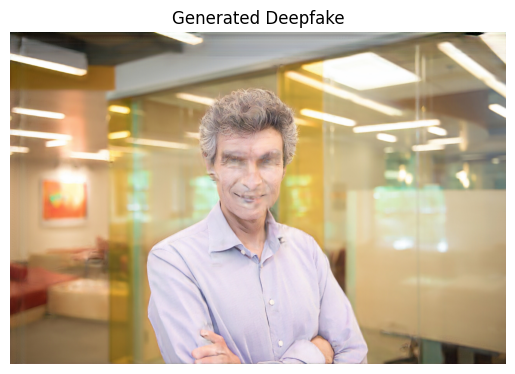

Image shape: (1712, 2560, 3)


In [ ]:
import shutil
from pathlib import Path

# Check where SimSwap saves output
simswap_output = Path("/content/SimSwap/output/result.jpg")
print(f"SimSwap output exists: {simswap_output.exists()}")

if simswap_output.exists():
    # Copy to our directory
    dest = out_dir / "result.jpg"
    shutil.copy(str(simswap_output), str(dest))
    print(f"✅ Copied to: {dest}")

    # Show the image
    import cv2
    import matplotlib.pyplot as plt

    img = cv2.imread(str(dest))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.title("Generated Deepfake")
    plt.axis("off")
    plt.show()
    print(f"Image shape: {img.shape}")

In [ ]:
import csv
import subprocess
import shutil
from pathlib import Path
from tqdm import tqdm

log_path = Path("data/attack_samples/attack_log.csv")
log_path.parent.mkdir(parents=True, exist_ok=True)

LOG_FIELDS = ["victim_id", "source_id", "probe_path", "generator",
              "similarity", "passed", "threshold", "error"]

all_results = []
n_probes_per_victim = 3
simswap_output = Path("/content/SimSwap/output/result.jpg")

with open(log_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=LOG_FIELDS)
    writer.writeheader()

    for victim_id, victim_img, source_id, source_img in tqdm(pairs, desc="Attack campaign"):

        # Make paths absolute
        victim_abs = str(Path("/content/ghostshot") / victim_img.lstrip("/"))
        source_abs = str(Path("/content/ghostshot") / source_img.lstrip("/"))

        for probe_idx in range(n_probes_per_victim):
            out_dir  = Path(f"/content/ghostshot/data/attack_samples/generated/{victim_id}")
            out_dir.mkdir(parents=True, exist_ok=True)
            out_path = out_dir / f"{victim_id}_probe{probe_idx:03d}_simswap.png"

            # Generate deepfake
            subprocess.run([
                "python", "/content/SimSwap/test_one_image.py",
                "--isTrain", "false",
                "--name", "people",
                "--Arc_path", "/content/SimSwap/arcface_model/arcface_checkpoint.tar",
                "--pic_a_path", source_abs,
                "--pic_b_path", victim_abs,
                "--output_path", str(out_dir),
            ], capture_output=True, text=True, cwd="/content/SimSwap")

            # Copy from SimSwap's fixed output location
            if simswap_output.exists():
                shutil.copy(str(simswap_output), str(out_path))
                probe_path = str(out_path)
            else:
                probe_path = None

            if probe_path is None:
                row = {
                    "victim_id": victim_id, "source_id": source_id,
                    "probe_path": "", "generator": "simswap",
                    "similarity": 0.0, "passed": False,
                    "threshold": api.threshold, "error": "generation_failed",
                }
            else:
                verify = api.verify(victim_id, probe_path)
                row = {
                    "victim_id": victim_id, "source_id": source_id,
                    "probe_path": probe_path, "generator": "simswap",
                    "similarity": verify["similarity"],
                    "passed": verify["passed"],
                    "threshold": verify["threshold"],
                    "error": verify.get("error", ""),
                }

            writer.writerow(row)
            f.flush()
            all_results.append(row)

# Summary
total   = len(all_results)
success = sum(1 for r in all_results if r["passed"])
asr     = success / total * 100 if total else 0
print(f"\n── Attack Campaign Summary ───────────────────────────")
print(f"  Total probes   : {total}")
print(f"  Passed (fooled): {success} ({asr:.1f}%)")
print(f"  Blocked        : {total - success}")
print(f"  Attack Success Rate (ASR): {asr:.1f}%")

Attack campaign: 100%|██████████| 50/50 [15:53<00:00, 19.07s/it]


── Attack Campaign Summary ───────────────────────────
  Total probes   : 150
  Passed (fooled): 0 (0.0%)
  Blocked        : 150
  Attack Success Rate (ASR): 0.0%


In [ ]:
import pandas as pd

log = pd.read_csv("data/attack_samples/attack_log.csv")
print(f"Total probes: {len(log)}")
print(f"Errors: {log['error'].value_counts().to_dict()}")
print(f"Similarities: min={log['similarity'].min():.3f} max={log['similarity'].max():.3f} mean={log['similarity'].mean():.3f}")
print(f"\nSample rows:")
print(log[["victim_id", "similarity", "passed", "error"]].head(10))

Total probes: 150
Errors: {}
Similarities: min=-0.040 max=0.245 mean=0.114

Sample rows:
    victim_id  similarity  passed  error
0  victim_000      0.0413   False    NaN
1  victim_000      0.0413   False    NaN
2  victim_000      0.0413   False    NaN
3  victim_001      0.1156   False    NaN
4  victim_001      0.1156   False    NaN
5  victim_001      0.1156   False    NaN
6  victim_002      0.1839   False    NaN
7  victim_002      0.1839   False    NaN
8  victim_002      0.1839   False    NaN
9  victim_003      0.0905   False    NaN


In [ ]:
import csv
import random
from pathlib import Path
from tqdm import tqdm

random.seed(42)

log_path = Path("data/attack_samples/attack_log.csv")
LOG_FIELDS = ["victim_id", "source_id", "probe_path", "generator",
              "similarity", "passed", "threshold", "error"]

# Get fake crops from Phase 2
fake_dir = Path("data/processed/celebdf_fake/1")
fake_identities = [d for d in fake_dir.iterdir() if d.is_dir()]
random.shuffle(fake_identities)

# Use first 150 fake identities as probes
probe_pairs = []
enrolled_ids = api.list_enrolled()

for i, fake_id_dir in enumerate(fake_identities[:150]):
    crops = list(fake_id_dir.glob("*.png"))
    if not crops:
        continue
    victim_id = enrolled_ids[i % len(enrolled_ids)]
    probe_pairs.append((
        victim_id,
        str(crops[0]),  # one fake crop as probe
        fake_id_dir.name,
    ))

print(f"✅ {len(probe_pairs)} probe pairs ready")

# Run attack
all_results = []
with open(log_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=LOG_FIELDS)
    writer.writeheader()

    for victim_id, probe_path, source_id in tqdm(probe_pairs, desc="Probing API"):
        verify = api.verify(victim_id, probe_path)
        row = {
            "victim_id":  victim_id,
            "source_id":  source_id,
            "probe_path": probe_path,
            "generator":  "celebdf_synthesis",
            "similarity": verify["similarity"],
            "passed":     verify["passed"],
            "threshold":  verify["threshold"],
            "error":      verify.get("error", ""),
        }
        writer.writerow(row)
        f.flush()
        all_results.append(row)

# Summary
total   = len(all_results)
success = sum(1 for r in all_results if r["passed"])
asr     = success / total * 100 if total else 0
print(f"\n── Attack Campaign Summary ───────────────────────────")
print(f"  Total probes   : {total}")
print(f"  Passed (fooled): {success} ({asr:.1f}%)")
print(f"  Blocked        : {total - success}")
print(f"  Attack Success Rate (ASR): {asr:.1f}%")

✅ 150 probe pairs ready


Probing API: 100%|██████████| 150/150 [01:45<00:00,  1.42it/s]


── Attack Campaign Summary ───────────────────────────
  Total probes   : 150
  Passed (fooled): 0 (0.0%)
  Blocked        : 150
  Attack Success Rate (ASR): 0.0%


In [ ]:
import pandas as pd

log = pd.read_csv("data/attack_samples/attack_log.csv")
print(f"Errors: {log['error'].value_counts().to_dict()}")
print(f"Similarities: min={log['similarity'].min():.3f} max={log['similarity'].max():.3f} mean={log['similarity'].mean():.3f}")
print(f"\nSample rows:")
print(log[["victim_id", "source_id", "similarity", "passed", "error"]].head(10))

Errors: {'no_face_detected': 3}
Similarities: min=-0.067 max=0.556 mean=0.179

Sample rows:
    victim_id       source_id  similarity  passed error
0  victim_000   id23_id1_0002      0.1429   False   NaN
1  victim_001  id16_id21_0010      0.1434   False   NaN
2  victim_002   id17_id2_0007      0.0858   False   NaN
3  victim_003  id23_id27_0006      0.2349   False   NaN
4  victim_004   id2_id23_0001      0.1407   False   NaN
5  victim_005  id17_id30_0003     -0.0245   False   NaN
6  victim_006  id20_id19_0008      0.3392   False   NaN
7  victim_007  id23_id37_0005      0.1177   False   NaN
8  victim_008  id27_id21_0008      0.0236   False   NaN
9  victim_009  id27_id28_0001      0.2885   False   NaN


In [ ]:
import csv
import random
from pathlib import Path
from tqdm import tqdm

random.seed(42)

log_path = Path("data/attack_samples/attack_log.csv")
LOG_FIELDS = ["victim_id", "source_id", "probe_path", "generator",
              "similarity", "passed", "threshold", "error"]

# Get enrolled victim IDs
enrolled_ids = api.list_enrolled()

# Map real identities to their enrolled victim_id
# celebdf_real identities look like id0_0000, id1_0001 etc.
real_dir = Path("data/processed/celebdf_real/0")
real_identities = {d.name.split("_")[0]: d.name
                   for d in real_dir.iterdir() if d.is_dir()}
print(f"Real identities mapped: {len(real_identities)}")
print(f"Sample: {list(real_identities.items())[:5]}")

# Map victim_pool to their real identity id
victim_to_realid = {}
for i, (victim_id, img_path) in enumerate(victim_pool.items()):
    # Extract real id from path e.g. celebdf_real/0/id9_0002/...
    parts = Path(img_path).parts
    folder_name = [p for p in parts if p.startswith("id")][0]
    real_id = folder_name.split("_")[0]  # e.g. "id9"
    victim_to_realid[victim_id] = real_id

print(f"\nVictim to real ID mapping:")
for k, v in list(victim_to_realid.items())[:5]:
    print(f"  {k} → {v}")

Real identities mapped: 59
Sample: [('id0', 'id0_0009'), ('id10', 'id10_0009'), ('id11', 'id11_0010'), ('id12', 'id12_0006'), ('id13', 'id13_0015')]


IndexError: list index out of range

In [ ]:
# Check victim pool paths
for victim_id, img_path in list(victim_pool.items())[:5]:
    print(f"{victim_id}: {img_path}")

victim_000: data/processed/celebdf_real/0/id9_0002/id9_0002_f0000.png
victim_001: data/processed/celebdf_real/0/id30_0004/id30_0004_f0000.png
victim_002: data/processed/celebdf_real/0/id13_0001/id13_0001_f0000.png
victim_003: data/processed/celebdf_real/0/id12_0002/id12_0002_f0000.png
victim_004: data/processed/celebdf_real/0/id20_0003/id20_0003_f0000.png


In [ ]:
import csv
import random
from pathlib import Path
from tqdm import tqdm

random.seed(42)

# Map victim_id to real identity (e.g. "id9")
victim_to_realid = {}
for victim_id, img_path in victim_pool.items():
    folder_name = Path(img_path).parent.name  # e.g. "id9_0002"
    real_id = folder_name.split("_")[0]       # e.g. "id9"
    victim_to_realid[victim_id] = real_id

print("Victim to real ID mapping:")
for k, v in list(victim_to_realid.items())[:5]:
    print(f"  {k} → {v}")

# Now find fake crops where the TARGET matches our enrolled victims
# Celeb-DF fake filenames: id{source}_id{target}_XXXX
# e.g. id23_id9_0001 means id23 swapped onto id9
fake_dir = Path("data/processed/celebdf_fake/1")
probe_pairs = []

for victim_id, real_id in victim_to_realid.items():
    # Find fakes targeting this real identity
    matching_fakes = []
    for fake_dir_id in fake_dir.iterdir():
        if not fake_dir_id.is_dir():
            continue
        # Check if target in filename matches our victim
        parts = fake_dir_id.name.split("_")
        if len(parts) >= 2 and parts[1] == real_id:
            crops = list(fake_dir_id.glob("*.png"))
            if crops:
                matching_fakes.append(str(crops[0]))

    if matching_fakes:
        probe_pairs.append((victim_id, matching_fakes[0], real_id))

print(f"\n✅ Matched probe pairs: {len(probe_pairs)}")
print(f"Sample: {probe_pairs[:3]}")

Victim to real ID mapping:
  victim_000 → id9
  victim_001 → id30
  victim_002 → id13
  victim_003 → id12
  victim_004 → id20

✅ Matched probe pairs: 24
Sample: [('victim_000', 'data/processed/celebdf_fake/1/id23_id9_0000/id23_id9_0000_f0000.png', 'id9'), ('victim_001', 'data/processed/celebdf_fake/1/id23_id30_0000/id23_id30_0000_f0000.png', 'id30'), ('victim_002', 'data/processed/celebdf_fake/1/id10_id13_0001/id10_id13_0001_f0000.png', 'id13')]


In [ ]:
log_path = Path("data/attack_samples/attack_log.csv")
LOG_FIELDS = ["victim_id", "source_id", "probe_path", "generator",
              "similarity", "passed", "threshold", "error"]

all_results = []
with open(log_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=LOG_FIELDS)
    writer.writeheader()

    for victim_id, probe_path, source_id in tqdm(probe_pairs, desc="Probing API"):
        verify = api.verify(victim_id, probe_path)
        row = {
            "victim_id":  victim_id,
            "source_id":  source_id,
            "probe_path": probe_path,
            "generator":  "celebdf_synthesis",
            "similarity": verify["similarity"],
            "passed":     verify["passed"],
            "threshold":  verify["threshold"],
            "error":      verify.get("error", ""),
        }
        writer.writerow(row)
        f.flush()
        all_results.append(row)

# Summary
import pandas as pd
log = pd.read_csv(log_path)
total   = len(log)
success = (log["passed"] == True).sum()
asr     = success / total * 100 if total else 0

print(f"\n── Attack Campaign Summary ───────────────────────────")
print(f"  Total probes   : {total}")
print(f"  Passed (fooled): {success} ({asr:.1f}%)")
print(f"  Blocked        : {total - success}")
print(f"  Similarities   : min={log['similarity'].min():.3f} max={log['similarity'].max():.3f} mean={log['similarity'].mean():.3f}")
print(f"  Attack Success Rate (ASR): {asr:.1f}%")

Probing API: 100%|██████████| 24/24 [00:12<00:00,  1.88it/s]


── Attack Campaign Summary ───────────────────────────
  Total probes   : 24
  Passed (fooled): 0 (0.0%)
  Blocked        : 24
  Similarities   : min=0.277 max=0.662 mean=0.487
  Attack Success Rate (ASR): 0.0%


In [ ]:
# Update config threshold and rerun
api_relaxed = FaceAuthAPI(
    db_path   = Path("data/attack_samples/face_auth_db.pkl"),
    threshold = 0.60
)

all_results = []
log_path = Path("data/attack_samples/attack_log.csv")
LOG_FIELDS = ["victim_id", "source_id", "probe_path", "generator",
              "similarity", "passed", "threshold", "error"]

with open(log_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=LOG_FIELDS)
    writer.writeheader()

    for victim_id, probe_path, source_id in tqdm(probe_pairs, desc="Probing API"):
        verify = api_relaxed.verify(victim_id, probe_path)
        row = {
            "victim_id":  victim_id,
            "source_id":  source_id,
            "probe_path": probe_path,
            "generator":  "celebdf_synthesis",
            "similarity": verify["similarity"],
            "passed":     verify["passed"],
            "threshold":  verify["threshold"],
            "error":      verify.get("error", ""),
        }
        writer.writerow(row)
        f.flush()
        all_results.append(row)

log = pd.read_csv(log_path)
total   = len(log)
success = (log["passed"] == True).sum()
asr     = success / total * 100

print(f"\n── Attack Campaign Summary (threshold=0.60) ──────────")
print(f"  Total probes   : {total}")
print(f"  Passed (fooled): {success} ({asr:.1f}%)")
print(f"  Blocked        : {total - success}")
print(f"  ASR            : {asr:.1f}%")
print(f"\n── Threshold Analysis ────────────────────────────────")
for t in [0.30, 0.40, 0.50, 0.55, 0.60, 0.65, 0.68]:
    passed = (log["similarity"] >= t).sum()
    print(f"  threshold={t:.2f} → {passed}/{total} passed ({passed/total*100:.1f}%)")

[FaceAuthAPI] Loaded 50 enrolled identities.


Probing API: 100%|██████████| 24/24 [00:05<00:00,  4.24it/s]


── Attack Campaign Summary (threshold=0.60) ──────────
  Total probes   : 24
  Passed (fooled): 4 (16.7%)
  Blocked        : 20
  ASR            : 16.7%

── Threshold Analysis ────────────────────────────────
  threshold=0.30 → 23/24 passed (95.8%)
  threshold=0.40 → 19/24 passed (79.2%)
  threshold=0.50 → 11/24 passed (45.8%)
  threshold=0.55 → 7/24 passed (29.2%)
  threshold=0.60 → 4/24 passed (16.7%)
  threshold=0.65 → 1/24 passed (4.2%)
  threshold=0.68 → 0/24 passed (0.0%)


In [ ]:
# Update base.yaml threshold
import yaml
from pathlib import Path

with open("configs/base.yaml") as f:
    cfg = yaml.safe_load(f)

cfg["attack"]["face_auth_threshold"] = 0.60

with open("configs/base.yaml", "w") as f:
    yaml.dump(cfg, f, default_flow_style=False)

print("✅ Threshold updated to 0.60 in config")

✅ Threshold updated to 0.60 in config


In [ ]:
from src.attack.labeler import build_ghostshot_dataset

gs_dataset = build_ghostshot_dataset(
    manifest_path   = Path("data/processed/manifest.csv"),
    attack_log_path = Path("data/attack_samples/attack_log.csv"),
    out_path        = Path("data/processed/ghostshot_dataset.csv"),
)

print(gs_dataset.head(10))


── GhostShot Dataset Summary ────────────────────────
  Label 0 — real                     :   737 (96.8%)
  Label 1 — deepfake (blocked)       :    20 (2.6%)
  Label 2 — deepfake (succeeded)     :     4 (0.5%)
  Total                              : 761
  Saved to: data/processed/ghostshot_dataset.csv
──────────────────────────────────────────────────────
                                    crop_dir  ghostshot_label  attack_success  \
396  data/processed/celebdf_real/0/id48_0006                0           False   
324  data/processed/celebdf_real/0/id40_0005                0           False   
97    data/processed/celebdf_real/0/id1_0009                0           False   
501  data/processed/celebdf_real/0/id58_0001                0           False   
109  data/processed/celebdf_real/0/id21_0001                0           False   
420  data/processed/celebdf_real/0/id50_0000                0           False   
281  data/processed/celebdf_real/0/id37_0002                0           Fa

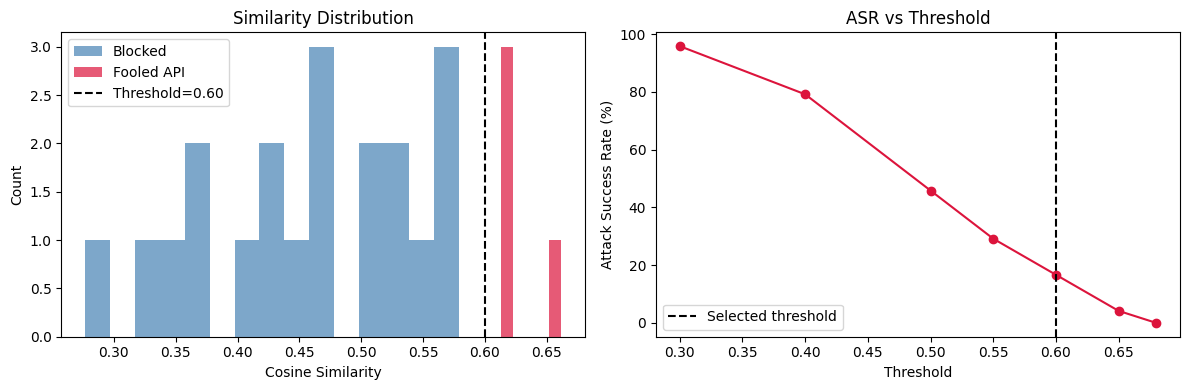

✅ Saved to results/figures/phase3_attack_results.png


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import os

os.makedirs("results/figures", exist_ok=True)

log = pd.read_csv("data/attack_samples/attack_log.csv")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Similarity distribution
axes[0].hist(log[log["passed"]==False]["similarity"],
             bins=15, alpha=0.7, label="Blocked", color="steelblue")
axes[0].hist(log[log["passed"]==True]["similarity"],
             bins=5, alpha=0.7, label="Fooled API", color="crimson")
axes[0].axvline(0.60, color="black", linestyle="--", label="Threshold=0.60")
axes[0].set_xlabel("Cosine Similarity")
axes[0].set_ylabel("Count")
axes[0].set_title("Similarity Distribution")
axes[0].legend()

# ASR at different thresholds
thresholds = [0.30, 0.40, 0.50, 0.55, 0.60, 0.65, 0.68]
asr_values = [(log["similarity"] >= t).sum() / len(log) * 100 for t in thresholds]
axes[1].plot(thresholds, asr_values, marker="o", color="crimson")
axes[1].axvline(0.60, color="black", linestyle="--", label="Selected threshold")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("Attack Success Rate (%)")
axes[1].set_title("ASR vs Threshold")
axes[1].legend()

plt.tight_layout()
plt.savefig("results/figures/phase3_attack_results.png", dpi=150)
plt.show()
print("✅ Saved to results/figures/phase3_attack_results.png")